<a href="https://colab.research.google.com/github/csanudo/AIBridge_bootcamp/blob/main/Lab_2_Level_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## LAB 2

1. Load and extract the red wine dataset.
2. Find the standard deviations of all of the features within the red wine dataset. Save it to a file.
3. Scale all features to 0-1. Save the scaled ataset.
4. Generate a histogram of the feature fixed acidity
5. Generate a plot comparing fixed acidity and volatile acidity. For fixed acidity, color all of the points that are within one stdev green, and all of the rest of the points red.

In [3]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Downloads and unzips wine data through UCI Database
!curl -O https://archive.ics.uci.edu/static/public/186/wine+quality.zip
!unzip wine+quality.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 91353    0 91353    0     0   354k      0 --:--:-- --:--:-- --:--:--  354k
Archive:  wine+quality.zip
replace winequality-red.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
# use pandas to read the CSV file
red_wine_df = pd.read_csv("winequality-red.csv", sep=';')
red_wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


2. Find the standard deviations of all of the features within the red wine dataset. Save it to a file

In [20]:
std_dev = red_wine_df.std()
mean = red_wine_df.mean()

print(std_dev)

fixed acidity            1.741096
volatile acidity         0.179060
citric acid              0.194801
residual sugar           1.409928
chlorides                0.047065
free sulfur dioxide     10.460157
total sulfur dioxide    32.895324
density                  0.001887
pH                       0.154386
sulphates                0.169507
alcohol                  1.065668
quality                  0.807569
dtype: float64


In [9]:
# std_dev to csv file
std_dev.to_csv("std_dev.csv")


3. Scale all features to 0-1. Save the scaled dataset.

In [10]:
max_val = red_wine_df.max()
scaled_df = red_wine_df / max_val
scaled_df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.465409,0.443038,0.00,0.122581,0.124386,0.152778,0.117647,0.994132,0.875312,0.280,0.630872,0.625
1,0.490566,0.556962,0.00,0.167742,0.160393,0.347222,0.231834,0.993135,0.798005,0.340,0.657718,0.625
2,0.490566,0.481013,0.04,0.148387,0.150573,0.208333,0.186851,0.993335,0.812968,0.325,0.657718,0.625
3,0.704403,0.177215,0.56,0.122581,0.122750,0.236111,0.207612,0.994331,0.788030,0.290,0.657718,0.750
4,0.465409,0.443038,0.00,0.122581,0.124386,0.152778,0.117647,0.994132,0.875312,0.280,0.630872,0.625


3. Generate a histogram of the feature fixed acidity

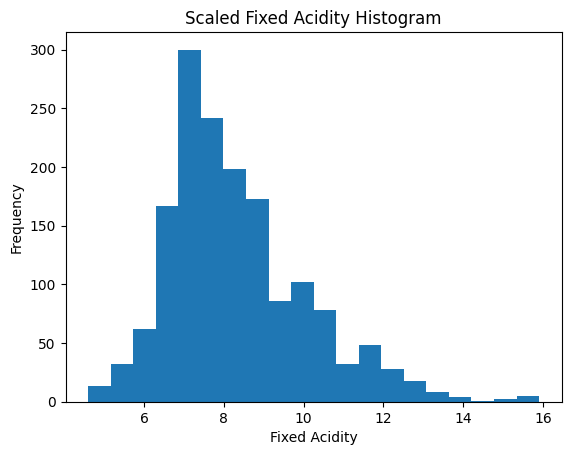

In [22]:
# i am using the scaled dataframe
plt.hist(red_wine_df["fixed acidity"], bins = 20)
plt.title("Scaled Fixed Acidity Histogram")
plt.xlabel("Fixed Acidity")
plt.ylabel("Frequency")
plt.show()

5. Generate a plot comparing fixed acidity and volatile acidity. For fixed acidity, color all of the points that are within one stdev green, and all of the rest of the points red.

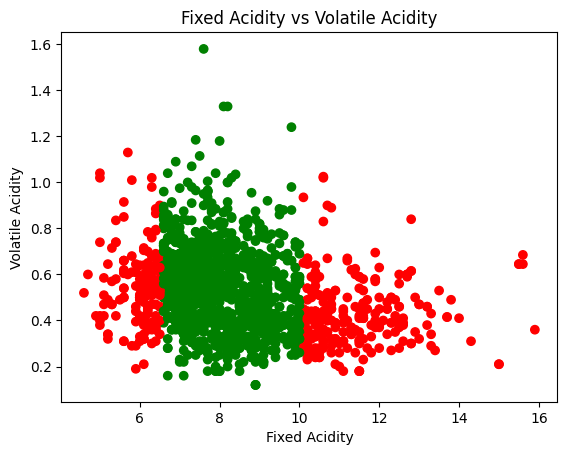

In [23]:
fixed_acidity_mean = mean["fixed acidity"]
fixed_acidity_std = std_dev["fixed acidity"]

lower_bound = fixed_acidity_mean - fixed_acidity_std
upper_bound = fixed_acidity_mean + fixed_acidity_std

colors = ['green' if (val >= lower_bound and val <= upper_bound) else 'red' for val in red_wine_df["fixed acidity"]]

plt.scatter(red_wine_df["fixed acidity"], red_wine_df["volatile acidity"], c=colors)
plt.title("Fixed Acidity vs Volatile Acidity")
plt.xlabel("Fixed Acidity")
plt.ylabel("Volatile Acidity")
plt.savefig('wine.png')
plt.show()